# SST in Mar 2023 in HRDPS 1km and HRDPS 2.5km Driven Results

## SST 

Date        : 20230301
Time index  : 0
HRDPS 1 time   : 2023-03-01T12:00:00.000000000
HRDPS time  : 2023-03-01T12:00:00.000000000
HRDPS 1 shape  : (898, 398)
HRDPS shape : (898, 398)
Date        : 20230315
Time index  : 14
HRDPS 1 time   : 2023-03-15T12:00:00.000000000
HRDPS time  : 2023-03-15T12:00:00.000000000
HRDPS 1 shape  : (898, 398)
HRDPS shape : (898, 398)
Date        : 20230328
Time index  : 27
HRDPS 1 time   : 2023-03-28T12:00:00.000000000
HRDPS time  : 2023-03-28T12:00:00.000000000
HRDPS 1 shape  : (898, 398)
HRDPS shape : (898, 398)

Color ranges:
SST  : 0.000 to 10.216 °C
Diff : -1.727 to 1.727 °C


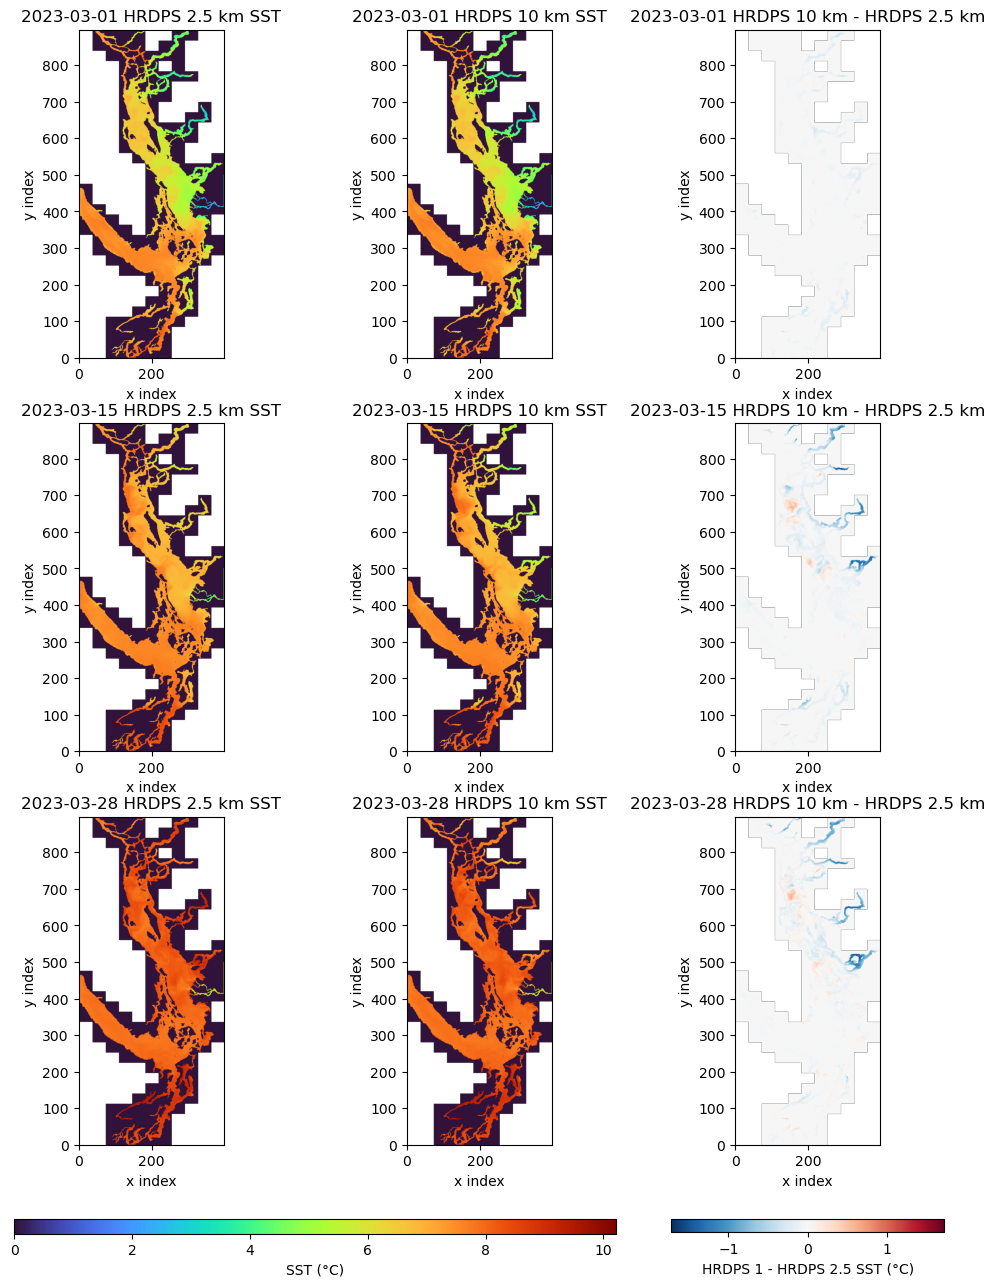

In [1]:
# HRDPS 1km vs HRDPS 2.5 km driven SST

import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm


# ============================================================
# 1d grid_T files
# ============================================================
path_grid_casr = (
    '/ocean/jqiu/results/Flux/flux_00mar23_hrdps10/'
    'SalishSea_1d_20230301_20230331_grid_T.nc'
)

path_grid_hrdps = (
    '/ocean/jqiu/results/Flux/flux_00mar23_hrdps2.5/'
    'SalishSea_1d_20230301_20230331_grid_T.nc'
)


# ============================================================
# Open datasets
# ============================================================
casr_ds = xr.open_dataset(path_grid_casr)
hrdps_ds = xr.open_dataset(path_grid_hrdps)


# ============================================================
# Choose 3 days
#
# For 1d monthly files:
# March 1  -> time index 0
# March 15 -> time index 14
# March 31 -> time index 30
# ============================================================
days = [
    "20230301",
    "20230315",
    "20230328",
]

day_numbers = [1, 15, 28]

depth_idx = 0


# ============================================================
# Read SST data
# ============================================================
all_data = []

for date_str, day_num in zip(days, day_numbers):

    # ========================================================
    # Time index for 1d monthly file
    # ========================================================
    tidx = day_num - 1


    # ========================================================
    # SST
    # ========================================================
    casr_sst = casr_ds['votemper'].isel(
        time_counter=tidx,
        deptht=depth_idx
    ).values

    hrdps_sst = hrdps_ds['votemper'].isel(
        time_counter=tidx,
        deptht=depth_idx
    ).values


    # ========================================================
    # Difference
    # positive = CaSR warmer than HRDPS
    # ========================================================
    diff = casr_sst - hrdps_sst


    # ========================================================
    # Time information
    # ========================================================
    casr_time = casr_ds.time_counter.isel(
        time_counter=tidx
    ).values

    hrdps_time = hrdps_ds.time_counter.isel(
        time_counter=tidx
    ).values


    print("=" * 60)
    print(f"Date        : {date_str}")
    print(f"Time index  : {tidx}")
    print(f"HRDPS 1 time   : {casr_time}")
    print(f"HRDPS time  : {hrdps_time}")
    print(f"HRDPS 1 shape  : {casr_sst.shape}")
    print(f"HRDPS shape : {hrdps_sst.shape}")


    # ========================================================
    # Save for plotting
    # ========================================================
    all_data.append({
        'date': date_str,
        'hrdps': hrdps_sst,
        'casr': casr_sst,
        'diff': diff,
    })


# ============================================================
# Unified SST color range
# across all 3 days and both datasets
# ============================================================
all_sst_values = []

for data in all_data:

    all_sst_values.append(
        data['hrdps'][np.isfinite(data['hrdps'])]
    )

    all_sst_values.append(
        data['casr'][np.isfinite(data['casr'])]
    )

all_sst_values = np.concatenate(all_sst_values)

sst_vmin = np.nanmin(all_sst_values)
sst_vmax = np.nanmax(all_sst_values)


# ============================================================
# Unified difference color range
# symmetric around zero
# ============================================================
all_diff_values = []

for data in all_data:

    all_diff_values.append(
        data['diff'][np.isfinite(data['diff'])]
    )

all_diff_values = np.concatenate(all_diff_values)

diff_max = np.nanmax(np.abs(all_diff_values))

diff_norm = TwoSlopeNorm(
    vmin=-diff_max,
    vcenter=0,
    vmax=diff_max
)


print("\nColor ranges:")
print(f"SST  : {sst_vmin:.3f} to {sst_vmax:.3f} °C")
print(f"Diff : {-diff_max:.3f} to {diff_max:.3f} °C")


# ============================================================
# Plot: 3 rows × 3 columns
#
# column 1: HRDPS SST
# column 2: CaSR SST
# column 3: CaSR - HRDPS
# ============================================================
fig, axes = plt.subplots(
    3,
    3,
    figsize=(12, 16)
)


for row, data in enumerate(all_data):

    date_str = data['date']

    hrdps_sst = data['hrdps']
    casr_sst = data['casr']
    diff = data['diff']

    date_label = (
        f'{date_str[:4]}-'
        f'{date_str[4:6]}-'
        f'{date_str[6:]}'
    )


    # ========================================================
    # HRDPS SST
    # ========================================================
    im_sst = axes[row, 0].imshow(
        hrdps_sst,
        origin='lower',
        cmap='turbo',
        vmin=sst_vmin,
        vmax=sst_vmax,
        aspect='equal'
    )

    axes[row, 0].set_title(
        f'{date_label} HRDPS 2.5 km SST'
    )

    axes[row, 0].set_xlabel('x index')
    axes[row, 0].set_ylabel('y index')


    # ========================================================
    # CaSR SST
    # ========================================================
    axes[row, 1].imshow(
        casr_sst,
        origin='lower',
        cmap='turbo',
        vmin=sst_vmin,
        vmax=sst_vmax,
        aspect='equal'
    )

    axes[row, 1].set_title(
        f'{date_label} HRDPS 10 km SST'
    )

    axes[row, 1].set_xlabel('x index')
    axes[row, 1].set_ylabel('y index')


    # ========================================================
    # Difference
    # ========================================================
    im_diff = axes[row, 2].imshow(
        diff,
        origin='lower',
        cmap='RdBu_r',
        norm=diff_norm,
        aspect='equal'
    )

    axes[row, 2].set_title(
        f'{date_label} HRDPS 10 km - HRDPS 2.5 km'
    )

    axes[row, 2].set_xlabel('x index')
    axes[row, 2].set_ylabel('y index')


# # ============================================================
# # Adjust space
# # leave space at bottom for horizontal colorbars
# # ============================================================
# plt.subplots_adjust(
#     left=0.07,
#     right=0.97,
#     top=0.95,
#     bottom=0.12,
#     wspace=0.15,
#     hspace=0.18
# )


# ============================================================
# SST colorbar
# shared by first two columns
# ============================================================
cbar_sst = fig.colorbar(
    im_sst,
    ax=axes[:, 0:2],
    orientation='horizontal',
    fraction=0.035,
    pad=0.06,
    aspect=40
)

cbar_sst.set_label('SST (°C)')


# ============================================================
# Difference colorbar
# shared by third column
# ============================================================
cbar_diff = fig.colorbar(
    im_diff,
    ax=axes[:, 2],
    orientation='horizontal',
    fraction=0.035,
    pad=0.06,
    aspect=20
)

cbar_diff.set_label('HRDPS 1 - HRDPS 2.5 SST (°C)')


plt.show()


# ============================================================
# Close files
# ============================================================
casr_ds.close()
hrdps_ds.close()